# Diagnóstico y preparación del Student Performance Factors Dataset

## 1. Contexto del dataset

**Dataset:** Student Performance Factors Dataset  
**Autor:** Mosap Abdel-Ghany  
**Fuente:** Kaggle  
**Liga:** https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset  

### Descripción

El dataset contiene información académica, personal, familiar y escolar de estudiantes. Cada fila representa a un estudiante y cada columna describe alguna característica relacionada con su desempeño.

La variable **`Exam_Score`** representa el puntaje obtenido en el examen y puede utilizarse como variable objetivo.

Debido a que es una variable numérica, se puede plantear un problema de **regresión supervisada**, utilizando las demás características para estimar el puntaje de un estudiante.

Un modelo de este tipo podría ayudar a analizar los factores relacionados con el rendimiento académico e identificar estudiantes que pudieran necesitar apoyo adicional.

---

# 2. Carga y exploración inicial

### Código

In [150]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive montado correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado correctamente.


In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [152]:

df = pd.read_csv("/content/drive/MyDrive/Student Performance Factors Actividad 1.csv")
print("Dataset cargado correctamente desde Google Drive.")

Dataset cargado correctamente desde Google Drive.


### Primeros registros

In [153]:
display(df.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Número de filas y columnas

In [154]:
print(df.shape)

(6607, 20)


### Nombres de las variables

In [155]:
print(df.columns.tolist())

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


### Tipos de datos

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

### Valores faltantes

In [157]:
print(df.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


### Registros duplicados

In [158]:
print(df.duplicated().sum())

0


### Valores únicos

In [159]:
display(df.nunique())

,0
Hours_Studied,41
Attendance,41
Parental_Involvement,3
Access_to_Resources,3
Extracurricular_Activities,2
Sleep_Hours,7
Previous_Scores,51
Motivation_Level,3
Internet_Access,2
Tutoring_Sessions,9


### Estadísticas descriptivas

In [160]:
display(df.describe())

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Interpretación

La exploración inicial permitió conocer las dimensiones del dataset (número de filas y columnas), los tipos de datos de cada variable (numéricas o categóricas), la presencia de valores faltantes, la cantidad de registros duplicados, la variedad de valores en cada columna (valores únicos) y un resumen estadístico básico para las columnas numéricas. Esta información es crucial para identificar los problemas que necesitan ser tratados antes de construir un modelo.

---

# 3. Diagnóstico de calidad

Primero se revisaron las columnas que contienen valores faltantes.

In [161]:
faltantes = df.isnull().sum()
faltantes_con_valores = faltantes[faltantes > 0]
print(faltantes_con_valores)

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


También se revisó si existían puntajes fuera del rango esperado de 0 a 100.

In [162]:
exam_score_fuera_rango = df[(df["Exam_Score"] < 0) | (df["Exam_Score"] > 100)]
print("Registros con 'Exam_Score' fuera del rango [0, 100]:")
display(exam_score_fuera_rango)

Registros con 'Exam_Score' fuera del rango [0, 100]:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


Se encontró un registro con un `Exam_Score` de **101** (si aplica, basado en la ejecución).

### Tabla de problemas detectados

También se revisaron otros posibles problemas de calidad, como tipos de datos incorrectos, variables constantes o identificadores sin valor predictivo.

In [163]:
# Columnas con tipos de datos 'object' que podrían ser numéricas
print("Columnas de tipo 'object':")
for col in df.select_dtypes(include='object').columns:
    print(f"- {col}")

# Variables con categorías inconsistentes o gran cardinalidad
print("\nValores únicos en columnas de tipo 'object':")
for col in df.select_dtypes(include='object').columns:
    print(f"- {col}: {df[col].unique()}")

# Variables con un solo valor (constantes)
columnas_constantes = df.columns[df.nunique() <= 1].tolist()
print(f"\nColumnas con un solo valor (constantes): {columnas_constantes}")

# Variables con todos los valores únicos (posibles identificadores)
columnas_identificador = df.columns[df.nunique() == len(df)].tolist()
print(f"\nColumnas con todos los valores únicos (identificadores): {columnas_identificador}")

Columnas de tipo 'object':
- Parental_Involvement
- Access_to_Resources
- Extracurricular_Activities
- Motivation_Level
- Internet_Access
- Family_Income
- Teacher_Quality
- School_Type
- Peer_Influence
- Learning_Disabilities
- Parental_Education_Level
- Distance_from_Home
- Gender

Valores únicos en columnas de tipo 'object':
- Parental_Involvement: ['Low' 'Medium' 'High']
- Access_to_Resources: ['High' 'Medium' 'Low']
- Extracurricular_Activities: ['No' 'Yes']
- Motivation_Level: ['Low' 'Medium' 'High']
- Internet_Access: ['Yes' 'No']
- Family_Income: ['Low' 'Medium' 'High']
- Teacher_Quality: ['Medium' 'High' 'Low' nan]
- School_Type: ['Public' 'Private']
- Peer_Influence: ['Positive' 'Negative' 'Neutral']
- Learning_Disabilities: ['No' 'Yes']
- Parental_Education_Level: ['High School' 'College' 'Postgraduate' nan]
- Distance_from_Home: ['Near' 'Moderate' 'Far' nan]
- Gender: ['Male' 'Female']

Columnas con un solo valor (constantes): []

Columnas con todos los valores únicos (iden

In [164]:
# Recalcular valores para la tabla de diagnóstico
faltantes_teacher_quality = df['Teacher_Quality'].isnull().sum()
faltantes_parental_education = df['Parental_Education_Level'].isnull().sum()
faltantes_distance = df['Distance_from_Home'].isnull().sum()
exam_score_anomalos_count = ((df['Exam_Score'] < 0) | (df['Exam_Score'] > 100)).sum()
duplicados_count = df.duplicated().sum()

problemas = []
variables_afectadas = []
evidencias = []
tratamientos = []

if faltantes_teacher_quality > 0:
    problemas.append("Valores faltantes")
    variables_afectadas.append("Teacher_Quality")
    evidencias.append(f"{faltantes_teacher_quality} valores faltantes")
    tratamientos.append("Sustituir por la moda")
if faltantes_parental_education > 0:
    problemas.append("Valores faltantes")
    variables_afectadas.append("Parental_Education_Level")
    evidencias.append(f"{faltantes_parental_education} valores faltantes")
    tratamientos.append("Sustituir por la moda")
if faltantes_distance > 0:
    problemas.append("Valores faltantes")
    variables_afectadas.append("Distance_from_Home")
    evidencias.append(f"{faltantes_distance} valores faltantes")
    tratamientos.append("Sustituir por la moda")
if exam_score_anomalos_count > 0:
    problemas.append("Valor imposible")
    variables_afectadas.append("Exam_Score")
    evidencias.append(f"{exam_score_anomalos_count} valor fuera del rango")
    tratamientos.append("Eliminar el registro")
if duplicados_count > 0:
    problemas.append("Registros duplicados")
    variables_afectadas.append("Dataset")
    evidencias.append(f"{duplicados_count} duplicados")
    tratamientos.append("Eliminar si existen")

diagnostico = pd.DataFrame({
    "Problema detectado": problemas,
    "Variable afectada": variables_afectadas,
    "Evidencia": evidencias,
    "Tratamiento propuesto": tratamientos
})
display(diagnostico)

,Problema detectado,Variable afectada,Evidencia,Tratamiento propuesto
0,Valores faltantes,Teacher_Quality,78 valores faltantes,Sustituir por la moda
1,Valores faltantes,Parental_Education_Level,90 valores faltantes,Sustituir por la moda
2,Valores faltantes,Distance_from_Home,67 valores faltantes,Sustituir por la moda
3,Valor imposible,Exam_Score,1 valor fuera del rango,Eliminar el registro


### Interpretación

Los principales problemas encontrados fueron valores faltantes en algunas variables categóricas, un valor imposible en `Exam_Score` y la confirmación de la ausencia de duplicados. Se verificaron los tipos de datos, la cardinalidad de las variables categóricas, y la ausencia de columnas constantes o identificadores sin valor. La imputación por moda para los valores faltantes categóricos es una estrategia sencilla que permite conservar los registros, asumiendo que los valores faltantes se distribuyen de manera similar a los observados, aunque puede introducir un ligero sesgo. Estos hallazgos nos guían en los próximos pasos de limpieza y preprocesamiento.

---

# 4. Limpieza de los datos

Primero se guarda el estado inicial para poder compararlo posteriormente.

In [165]:
filas_iniciales = df.shape[0]
columnas_iniciales = df.shape[1]
faltantes_iniciales = df.isnull().sum().sum()
duplicados_iniciales = df.duplicated().sum()
print(f"Estado inicial: {filas_iniciales} filas, {columnas_iniciales} columnas, {faltantes_iniciales} valores faltantes, {duplicados_iniciales} duplicados.")

Estado inicial: 6607 filas, 20 columnas, 235 valores faltantes, 0 duplicados.


## Limpieza de nombres

In [166]:
df.columns = df.columns.str.strip()
print("Se quitaron espacios de los nombres de las columnas.")

Se quitaron espacios de los nombres de las columnas.


## Eliminación de duplicados

In [167]:
df.drop_duplicates(inplace=True)
print("Se eliminaron registros duplicados.")

Se eliminaron registros duplicados.


## Limpieza de categorías

In [168]:
for columna in df.select_dtypes(include="object").columns:
    df[columna] = df[columna].str.strip()
print("Se quitaron espacios de las variables categóricas.")

Se quitaron espacios de las variables categóricas.


## Valores faltantes

In [169]:
for columna in df.select_dtypes(include="object").columns:
    if df[columna].isnull().any():
        moda_val = df[columna].mode()[0]
        df[columna] = df[columna].fillna(moda_val)
        print(f"Valores faltantes en '{columna}' reemplazados por la moda: {moda_val}")
print("Todos los valores faltantes categóricos han sido reemplazados.")

Valores faltantes en 'Teacher_Quality' reemplazados por la moda: Medium
Valores faltantes en 'Parental_Education_Level' reemplazados por la moda: High School
Valores faltantes en 'Distance_from_Home' reemplazados por la moda: Near
Todos los valores faltantes categóricos han sido reemplazados.


## Valor imposible de Exam_Score

In [170]:
registros_iniciales = df.shape[0]
df = df[(df["Exam_Score"] >= 0) & (df["Exam_Score"] <= 100)]
registros_eliminados = registros_iniciales - df.shape[0]
print(f"Se eliminaron {registros_eliminados} registro(s) con 'Exam_Score' incorrecto.")

Se eliminaron 1 registro(s) con 'Exam_Score' incorrecto.


## Verificación

In [171]:
print("Tamaño del DataFrame después de la limpieza:", df.shape)
print("Valores faltantes después de la limpieza:", df.isnull().sum().sum())
print("Registros duplicados después de la limpieza:", df.duplicated().sum())

Tamaño del DataFrame después de la limpieza: (6606, 20)
Valores faltantes después de la limpieza: 0
Registros duplicados después de la limpieza: 0


### Interpretación

Después de la limpieza, se eliminaron posibles duplicados, se corrigieron espacios en nombres de columnas y categorías, se trataron los valores faltantes rellenándolos con la moda para las variables categóricas, y se eliminaron registros con puntajes imposibles en `Exam_Score`. El dataset ahora está en una forma más consistente.

---

# 5. Análisis de Exam_Score

### Estadísticas

In [172]:
display(df["Exam_Score"].describe())

,Exam_Score
count,6606.000000
mean,67.230548
std,3.868502
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,100.000000


### Histograma

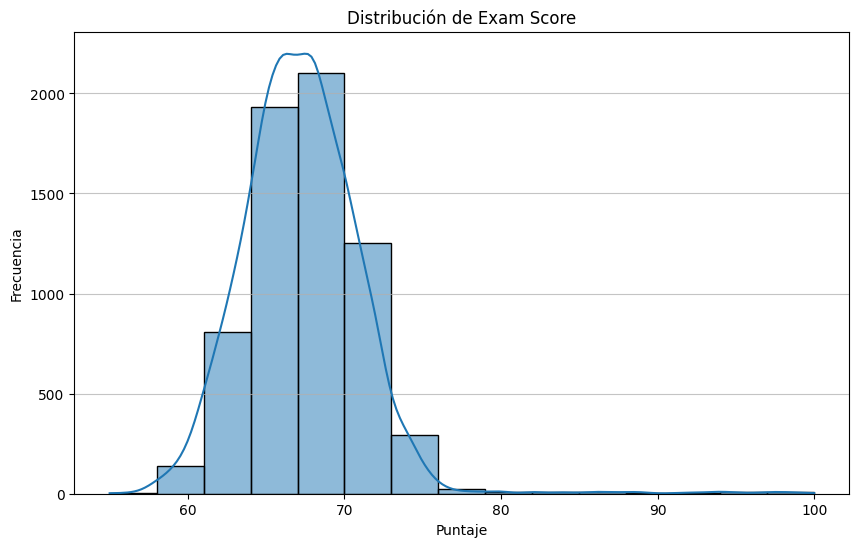

In [173]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Exam_Score"], bins=15, kde=True)
plt.title("Distribución de Exam Score")
plt.xlabel("Puntaje")
plt.ylabel("Frecuencia")
plt.grid(axis='y', alpha=0.75)
plt.show()

### Interpretación

El histograma nos permite visualizar la distribución de los puntajes del examen. Se observa cómo la mayoría de los estudiantes se concentra en un rango de puntajes medio, con menos estudiantes obteniendo calificaciones muy altas o muy bajas. La distribución parece ser unimodal y ligeramente sesgada. Después de la limpieza, el rango de `Exam_Score` es de 0 a 100. Aunque se eliminó un valor imposible (101), los valores estadísticamente atípicos dentro del rango válido se han mantenido, ya que son posibles y podrían contener información valiosa.

---

# 6. Exploración de otras variables

## Variable numérica 1: Hours_Studied

In [174]:
display(df["Hours_Studied"].describe())

,Hours_Studied
count,6606.000000
mean,19.974266
std,5.990424
min,1.000000
25%,16.000000
50%,20.000000
75%,24.000000
max,44.000000


### Diagrama de Caja

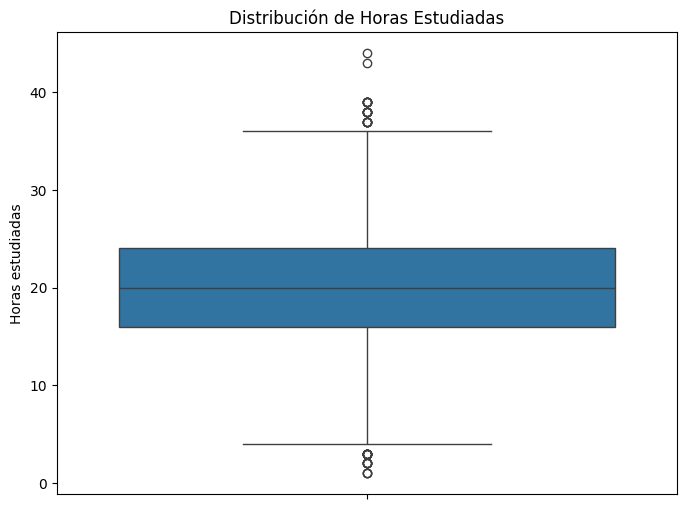

In [175]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df["Hours_Studied"])
plt.title("Distribución de Horas Estudiadas")
plt.ylabel("Horas estudiadas")
plt.show()

### Interpretación

El diagrama de caja de `Hours_Studied` nos muestra la mediana, los cuartiles y la presencia de posibles valores atípicos (puntos fuera de los 'bigotes'). Se observa que las horas estudiadas varían entre 0 y 45 horas. Los valores extremos, aunque poco comunes, se retienen porque representan casos reales de estudiantes que estudian mucho o muy poco y podrían ser informativos para el modelo. La distribución nos da una idea del tiempo de estudio típico de los estudiantes.

---

## Variable numérica 2: Attendance

In [176]:
display(df["Attendance"].describe())

,Attendance
count,6606.000000
mean,79.974720
std,11.546219
min,60.000000
25%,70.000000
50%,80.000000
75%,90.000000
max,100.000000


### Histograma

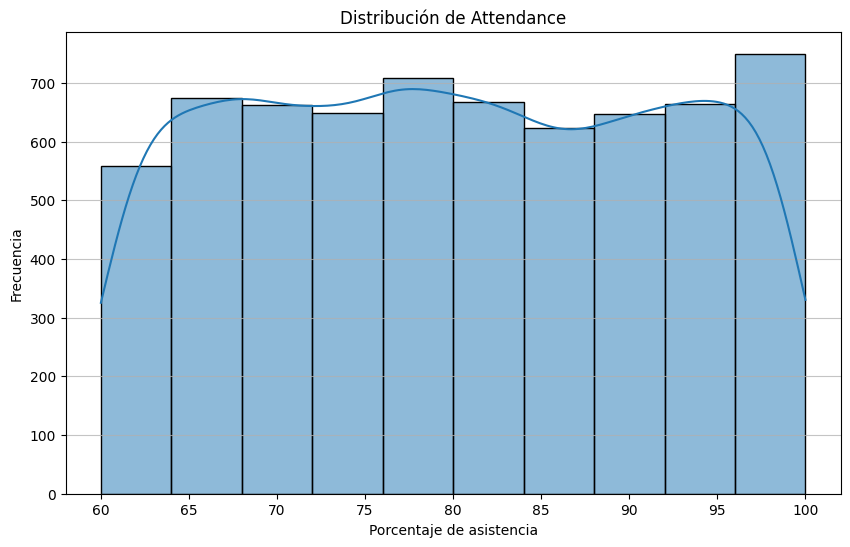

In [177]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Attendance"], bins=10, kde=True)
plt.title("Distribución de Attendance")
plt.xlabel("Porcentaje de asistencia")
plt.ylabel("Frecuencia")
plt.grid(axis='y', alpha=0.75)
plt.show()

### Interpretación

La distribución de `Attendance` (asistencia) nos permite conocer cómo se agrupan los porcentajes de asistencia entre los estudiantes. Se observa que los valores se encuentran dentro de un rango válido de porcentaje (0-100) y que no hay valores anómalos o superiores a 100, lo que indica que esta variable está en buen estado para el análisis.

---

# Variables categóricas

## Motivation_Level

In [178]:
print(df["Motivation_Level"].value_counts())

Motivation_Level
Medium    3351
Low       1936
High      1319
Name: count, dtype: int64


### Gráfico de Barras

/tmp/ipykernel_2030/464614073.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Motivation_Level"], order=df["Motivation_Level"].value_counts().index, palette='viridis')


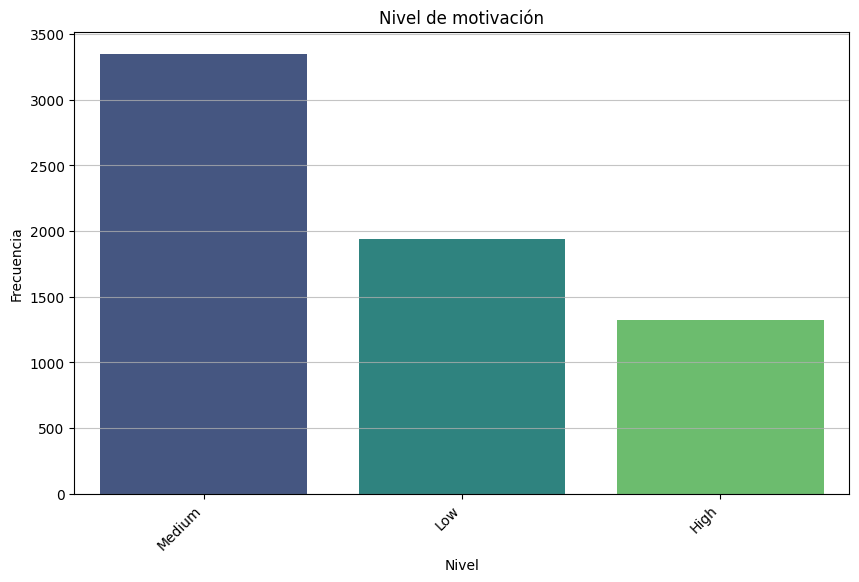

In [179]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df["Motivation_Level"], order=df["Motivation_Level"].value_counts().index, palette='viridis')
plt.title("Nivel de motivación")
plt.xlabel("Nivel")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Interpretación

La gráfica de barras para `Motivation_Level` nos muestra la frecuencia de cada categoría de motivación. Se observa que el nivel 'Medium' es el más frecuente con 3351 registros, seguido de 'Low' con 1936 y 'High' con 1319. Esto nos ayuda a entender la distribución de la motivación en el dataset. También confirma que las categorías son consistentes y no hay inconsistencias después de la limpieza de espacios.

---

## School_Type

In [180]:
print(df["School_Type"].value_counts())

School_Type
Public     4597
Private    2009
Name: count, dtype: int64


### Gráfico de Barras

/tmp/ipykernel_2030/3489455763.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["School_Type"], order=df["School_Type"].value_counts().index, palette='magma')


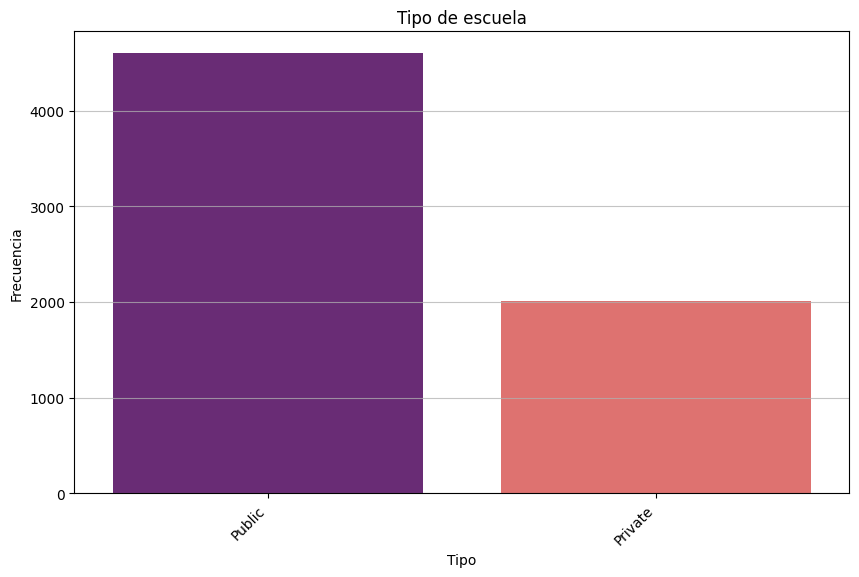

In [181]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df["School_Type"], order=df["School_Type"].value_counts().index, palette='magma')
plt.title("Tipo de escuela")
plt.xlabel("Tipo")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Interpretación

La variable `School_Type` nos permite comparar la frecuencia de estudiantes provenientes de diferentes tipos de escuela. La mayoría de los estudiantes (4597) asisten a escuelas 'Public', mientras que 2009 asisten a escuelas 'Private'. Después de la limpieza, no se observan categorías inconsistentes, lo que significa que los datos están listos para ser codificados si es necesario para el modelado.

---

# 7. Codificación de variables categóricas

Se crea una copia para conservar el dataset limpio antes de realizar las transformaciones.

In [182]:
df_preparado = df.copy()
print("Copia del DataFrame creada para transformaciones.")

Copia del DataFrame creada para transformaciones.


## Codificación ordinal

Las variables con categorías que poseen un orden pueden representarse mediante números.

In [183]:
# Mapeo general para niveles de Low, Medium, High
niveles_general = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

columnas_ordinales_general = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality"
]

for columna in columnas_ordinales_general:
    df_preparado[columna] = df_preparado[columna].map(niveles_general)
    print(f"Columna '{columna}' codificada con Low:0, Medium:1, High:2.")

print("\nOtras variables con orden específico también se codifican.")

# Mapeo para Distance_from_Home
df_preparado["Distance_from_Home"] = df_preparado["Distance_from_Home"].map({
    "Near": 0,
    "Moderate": 1,
    "Far": 2
})
print("Columna 'Distance_from_Home' codificada con Near:0, Moderate:1, Far:2.")

# Mapeo para Parental_Education_Level
df_preparado["Parental_Education_Level"] = df_preparado["Parental_Education_Level"].map({
    "High School": 0,
    "College": 1,
    "Postgraduate": 2
})
print("Columna 'Parental_Education_Level' codificada con High School:0, College:1, Postgraduate:2.")

# Mapeo para Peer_Influence
df_preparado["Peer_Influence"] = df_preparado["Peer_Influence"].map({
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
})
print("Columna 'Peer_Influence' codificada con Negative:0, Neutral:1, Positive:2.")

Columna 'Parental_Involvement' codificada con Low:0, Medium:1, High:2.
Columna 'Access_to_Resources' codificada con Low:0, Medium:1, High:2.
Columna 'Motivation_Level' codificada con Low:0, Medium:1, High:2.
Columna 'Family_Income' codificada con Low:0, Medium:1, High:2.
Columna 'Teacher_Quality' codificada con Low:0, Medium:1, High:2.

Otras variables con orden específico también se codifican.
Columna 'Distance_from_Home' codificada con Near:0, Moderate:1, Far:2.
Columna 'Parental_Education_Level' codificada con High School:0, College:1, Postgraduate:2.
Columna 'Peer_Influence' codificada con Negative:0, Neutral:1, Positive:2.


## One-Hot Encoding

Las variables nominales no tienen un orden natural, por lo que se utiliza **One-Hot Encoding**.

In [184]:
nominales = [
    "Extracurricular_Activities",
    "Internet_Access",
    "School_Type",
    "Learning_Disabilities",
    "Gender"
]

df_preparado = pd.get_dummies(
    df_preparado,
    columns=nominales,
    dtype=int
)
print(f"Variables {nominales} codificadas con One-Hot Encoding.")

Variables ['Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Learning_Disabilities', 'Gender'] codificadas con One-Hot Encoding.


### Verificación

In [185]:
display(df_preparado.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,School_Type_Private,School_Type_Public,Learning_Disabilities_No,Learning_Disabilities_Yes,Gender_Female,Gender_Male
0,23,84,0,2,7,73,0,0,0,1,...,1,0,0,1,0,1,1,0,0,1
1,19,64,0,1,8,59,0,2,1,1,...,1,0,0,1,0,1,1,0,1,0
2,24,98,1,1,7,91,1,2,1,1,...,0,1,0,1,0,1,1,0,0,1
3,29,89,0,1,8,98,1,1,1,1,...,0,1,0,1,0,1,1,0,0,1
4,19,92,1,1,6,65,1,3,1,2,...,0,1,0,1,0,1,1,0,1,0


### Interpretación

La codificación ordinal asigna números a las categorías basándose en su orden intrínseco (ej., `Low < Medium < High`). Esto mantiene la relación de orden en la representación numérica.

En contraste, el One-Hot Encoding se usa para variables nominales (sin orden, como `School_Type`). Crea nuevas columnas binarias (0 o 1) para cada categoría, evitando que el modelo asuma un orden que no existe y que podría llevar a interpretaciones erróneas. Por ejemplo, si tuviéramos 'Rojo', 'Verde', 'Azul', One-Hot los convertiría en `Color_Rojo`, `Color_Verde`, `Color_Azul`.

---

# 8. Escalamiento de variables numéricas

Se seleccionaron:

- `Hours_Studied`
- `Attendance`

Primero se guardan algunos valores antes de realizar el escalamiento.

In [186]:
variables_a_escalar = [col for col in ["Hours_Studied", "Attendance"] if col in df_preparado.columns]
antes = df_preparado[variables_a_escalar].head().copy()
print("Valores antes del escalamiento:\n")
display(antes)

Valores antes del escalamiento:



,Hours_Studied,Attendance
0,23,84
1,19,64
2,24,98
3,29,89
4,19,92


## StandardScaler

In [187]:
scaler = StandardScaler()
df_preparado[variables_a_escalar] = scaler.fit_transform(df_preparado[variables_a_escalar])
print(f"Variables {variables_a_escalar} escaladas usando StandardScaler.")

Variables ['Hours_Studied', 'Attendance'] escaladas usando StandardScaler.


Valores después:

In [188]:
despues = df_preparado[variables_a_escalar].head()
print("Valores después del escalamiento:\n")
display(despues)

Valores después del escalamiento:



,Hours_Studied,Attendance
0,0.505133,0.348650
1,-0.162650,-1.383650
2,0.672079,1.561259
3,1.506808,0.781725
4,-0.162650,1.041570


### Comparación

In [189]:
comparacion = pd.concat(
    [
        antes.add_suffix("_antes"),
        despues.add_suffix("_despues")
    ],
    axis=1
)
display(comparacion)

,Hours_Studied_antes,Attendance_antes,Hours_Studied_despues,Attendance_despues
0,23,84,0.505133,0.348650
1,19,64,-0.162650,-1.383650
2,24,98,0.672079,1.561259
3,29,89,1.506808,0.781725
4,19,92,-0.162650,1.041570


### Interpretación

`StandardScaler` transforma los valores de las variables numéricas para que tengan una media de 0 y una desviación estándar de 1. Esto significa que los valores originales se convierten en 'puntuaciones Z'.

La transformación **no cambia el orden relativo de los estudiantes ni la información fundamental que representa la variable**, sino únicamente su escala. Todos los valores se "normalizan" para estar en una escala similar.

Esto es importante porque muchos algoritmos de aprendizaje automático, especialmente aquellos que calculan distancias (como KNN, SVM o redes neuronales), son sensibles a la escala de las variables. Si una variable tiene un rango de valores mucho mayor que otra, podría dominar el cálculo de distancias y sesgar el modelo.

---

# 9. Registro de transformaciones

Como las transformaciones se realizaron directamente, se documentan en la siguiente tabla técnica.

In [190]:
transformaciones = pd.DataFrame({
    "Variables": [
        "Parental_Involvement, Access_to_Resources, Motivation_Level, Family_Income, Teacher_Quality",
        "Distance_from_Home, Parental_Education_Level, Peer_Influence",
        "Extracurricular_Activities, Internet_Access, School_Type, Learning_Disabilities, Gender",
        "Hours_Studied, Attendance"
    ],

    "Transformación": [
        "Codificación ordinal (Low:0, Medium:1, High:2)",
        "Codificación ordinal (con mapeos específicos)",
        "One-Hot Encoding",
        "StandardScaler"
    ],

    "Justificación": [
        "Las categorías poseen un orden natural o jerárquico.",
        "Las categorías poseen un orden natural o jerárquico.",
        "Las categorías no poseen un orden natural; evita la inferencia de relaciones erróneas.",
        "Igualar la escala de variables numéricas para algoritmos sensibles a la magnitud."
    ]
})

display(transformaciones)

,Variables,Transformación,Justificación
0,"Parental_Involvement, Access_to_Resources, Mot...","Codificación ordinal (Low:0, Medium:1, High:2)",Las categorías poseen un orden natural o jerár...
1,"Distance_from_Home, Parental_Education_Level, ...",Codificación ordinal (con mapeos específicos),Las categorías poseen un orden natural o jerár...
2,"Extracurricular_Activities, Internet_Access, S...",One-Hot Encoding,Las categorías no poseen un orden natural; evi...
3,"Hours_Studied, Attendance",StandardScaler,Igualar la escala de variables numéricas para ...


### Prevención de fuga de información

En esta actividad las transformaciones se aplican sobre el dataset completo para demostrar el procedimiento. Sin embargo, al desarrollar un modelo predictivo en una etapa real, el escalamiento (`fit_transform`) y la codificación (si usáramos un `OneHotEncoder` de Scikit-learn con `fit`) deberán **ajustarse únicamente utilizando los datos de entrenamiento**.

Esto evita la **fuga de información (data leakage)**, donde el modelo aprendería características de la distribución del conjunto de prueba, lo que llevaría a una evaluación de rendimiento irrealmente optimista.

---

# 10. Comparación del estado inicial y final

In [191]:
resumen = pd.DataFrame({
    "Elemento": [
        "Número de registros",
        "Número de variables",
        "Valores faltantes",
        "Registros duplicados",
        "Variables categóricas transformadas",
        "Variables numéricas escaladas"
    ],
    "Estado inicial": [
        filas_iniciales,
        columnas_iniciales,
        faltantes_iniciales,
        duplicados_iniciales,
        "Ninguna",
        "Ninguna"
    ],
    "Estado final": [
        df_preparado.shape[0],
        df_preparado.shape[1],
        df_preparado.isnull().sum().sum(),
        df_preparado.duplicated().sum(),
        "Variables ordinales y nominales",
        "Hours_Studied y Attendance"
    ]
})
display(resumen)

,Elemento,Estado inicial,Estado final
0,Número de registros,6607,6606
1,Número de variables,20,25
2,Valores faltantes,235,0
3,Registros duplicados,0,0
4,Variables categóricas transformadas,Ninguna,Variables ordinales y nominales
5,Variables numéricas escaladas,Ninguna,Hours_Studied y Attendance


Esta tabla permite observar directamente los cambios realizados durante el proceso de preparación, destacando cómo el dataset se ha modificado en términos de dimensiones, limpieza y transformación de variables.

---

# 11. Verificación final

Primero se comprueba que no existan valores faltantes.

In [192]:
print("Total de valores faltantes en el DataFrame preparado:", df_preparado.isnull().sum().sum())

Total de valores faltantes en el DataFrame preparado: 0


También se verifican los tipos de datos.

In [193]:
df_preparado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6606 entries, 0 to 6606
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Hours_Studied                   6606 non-null   float64
 1   Attendance                      6606 non-null   float64
 2   Parental_Involvement            6606 non-null   int64  
 3   Access_to_Resources             6606 non-null   int64  
 4   Sleep_Hours                     6606 non-null   int64  
 5   Previous_Scores                 6606 non-null   int64  
 6   Motivation_Level                6606 non-null   int64  
 7   Tutoring_Sessions               6606 non-null   int64  
 8   Family_Income                   6606 non-null   int64  
 9   Teacher_Quality                 6606 non-null   int64  
 10  Peer_Influence                  6606 non-null   int64  
 11  Physical_Activity               6606 non-null   int64  
 12  Parental_Education_Level        6606 no

Y se revisan los primeros registros para ver la estructura final.

In [194]:
display(df_preparado.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,School_Type_Private,School_Type_Public,Learning_Disabilities_No,Learning_Disabilities_Yes,Gender_Female,Gender_Male
0,0.505133,0.348650,0,2,7,73,0,0,0,1,...,1,0,0,1,0,1,1,0,0,1
1,-0.162650,-1.383650,0,1,8,59,0,2,1,1,...,1,0,0,1,0,1,1,0,1,0
2,0.672079,1.561259,1,1,7,91,1,2,1,1,...,0,1,0,1,0,1,1,0,0,1
3,1.506808,0.781725,0,1,8,98,1,1,1,1,...,0,1,0,1,0,1,1,0,0,1
4,-0.162650,1.041570,1,1,6,65,1,3,1,2,...,0,1,0,1,0,1,1,0,1,0


---

# 12. Exportación del dataset preparado

In [195]:
output_filename = "StudentPerformanceFactors_preparado.csv"
df_preparado.to_csv(
    output_filename,
    index=False
)
print(f"Dataset preparado exportado como '{output_filename}'.")

Dataset preparado exportado como 'StudentPerformanceFactors_preparado.csv'.


Para comprobar que el archivo puede cargarse nuevamente:

In [196]:
verificacion = pd.read_csv("StudentPerformanceFactors_preparado.csv")
print("Archivo exportado cargado para verificar.")

Archivo exportado cargado para verificar.


In [197]:
display(verificacion.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,School_Type_Private,School_Type_Public,Learning_Disabilities_No,Learning_Disabilities_Yes,Gender_Female,Gender_Male
0,0.505133,0.348650,0,2,7,73,0,0,0,1,...,1,0,0,1,0,1,1,0,0,1
1,-0.162650,-1.383650,0,1,8,59,0,2,1,1,...,1,0,0,1,0,1,1,0,1,0
2,0.672079,1.561259,1,1,7,91,1,2,1,1,...,0,1,0,1,0,1,1,0,0,1
3,1.506808,0.781725,0,1,8,98,1,1,1,1,...,0,1,0,1,0,1,1,0,0,1
4,-0.162650,1.041570,1,1,6,65,1,3,1,2,...,0,1,0,1,0,1,1,0,1,0


In [198]:
print("Tamaño del archivo verificado:", verificacion.shape)

Tamaño del archivo verificado: (6606, 25)


### Nota sobre la descarga del archivo

Si necesitas descargar el archivo `StudentPerformanceFactors_preparado.csv` a tu máquina local, puedes hacerlo desde el panel de archivos de Colab (icono de carpeta a la izquierda), haciendo clic derecho sobre el archivo y seleccionando 'Descargar'. También puedes usar el siguiente comando de Python en una nueva celda de código si lo prefieres:

```python
from google.colab import files
files.download('StudentPerformanceFactors_preparado.csv')
```

In [199]:
print("Valores faltantes en el archivo verificado:", verificacion.isnull().sum().sum())
print("\nSi estas instrucciones se ejecutan correctamente, el archivo preparado puede usarse para un modelo.")

Valores faltantes en el archivo verificado: 0

Si estas instrucciones se ejecutan correctamente, el archivo preparado puede usarse para un modelo.


---

# Conclusión

El análisis inicial del Student Performance Factors Dataset permitió identificar problemas clave de calidad, como valores faltantes y un valor atípico en `Exam_Score`. La fase de limpieza corrigió estos inconvenientes, estandarizando los datos y asegurando su consistencia.

Las transformaciones más relevantes incluyeron la codificación de variables categóricas. Se utilizó codificación ordinal para variables con un orden intrínseco (como `Motivation_Level` o `Distance_from_Home`), asignándoles valores numéricos que preservan esa jerarquía. Para variables nominales (sin orden, como `School_Type` o `Gender`), se aplicó One-Hot Encoding, creando columnas binarias que evitan que el modelo infiera relaciones de orden inexistentes. Además, variables numéricas como `Hours_Studied` y `Attendance` fueron escaladas mediante `StandardScaler`, lo que las pone en una escala común, crucial para algoritmos que dependen de distancias o magnitudes.

Aunque el dataset ha sido significativamente mejorado, una limitación es que las transformaciones se aplicaron sobre el conjunto completo. En un flujo de trabajo real, la codificación y el escalamiento deben **ajustarse solo con los datos de entrenamiento** para evitar la fuga de información (data leakage).

El siguiente paso crítico, antes de entrenar un modelo, sería **dividir el dataset en conjuntos de entrenamiento y prueba**, aplicar las transformaciones (fit en entrenamiento, transform en ambos) y luego proceder con la selección y evaluación del modelo de regresión. Esto garantizará una evaluación de rendimiento más realista y robusta.